# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install Python
Anaconda3-5.2.0-Windows-x86_64.exe:

Python 3.6.5 |Anaconda, Inc.| (default, Mar 29 2018, 13:32:41) [MSC v.1900 64 bit (AMD64)]

Microsoft Visual Studio Professional 2017 Version 15.8.9

PTVS 15.8.18241.1-15.0

## Install PT3S to site-packages

In [1]:
###!pip uninstall --yes PT3S
###!pip install PT3S --no-cache-dir

## OR use local PT3S under Development

In [2]:
###!pip install -e .

## Logging

In [3]:
import logging
import os
logger = logging.getLogger('PT3S')  


logFileName= r"PT3S-Notebook.log"        
loglevel = logging.DEBUG
logging.basicConfig(filename=logFileName
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFileName)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

## about from PT3S ... import ... and pip install -e .

In [4]:
#%pwd

In [5]:
# works only if pip install -e .is NOT active:
###from PT3S import Mx,Xm,Rm
# or if subdir is PT3S
#%cd -q ..
# ...
#%cd -q PT3S 

In [6]:
# if pip install -e .IS active
# the local modules can be imported with:
import Mx, Xm, Rm
# if %pwd is local devdir

# ggf. Tests

In [7]:
%run test.py -q -m 0 -s Mx -s Xm

INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata


Finding tests in Mx


.
----------------------------------------------------------------------
Ran 1 test in 7.872s

OK


Finding tests in Xm


.
----------------------------------------------------------------------
Ran 1 test in 41.879s

OK


Finding tests in Rm


.
----------------------------------------------------------------------
Ran 1 test in 22.372s

OK
INFO    ; __main__.<module>: Start doctests. testDir: testdata
INFO    ; __main__.<module>: Start doctests. testDir: testdata
INFO    ; __main__.<module>: Start doctests. testDir: testdata


Finding tests in Mx
Finding tests in Xm
Finding tests in Rm


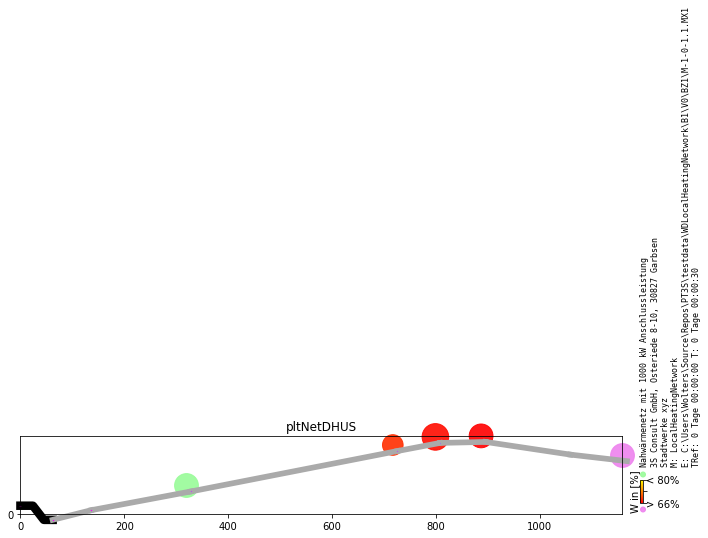

In [8]:
%run test.py

INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata10
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata10
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata10
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata10


Finding tests in Mx


.
----------------------------------------------------------------------
Ran 1 test in 27.385s

OK


Finding tests in Xm


.
----------------------------------------------------------------------
Ran 1 test in 70.911s

OK


Finding tests in Rm


.
----------------------------------------------------------------------
Ran 1 test in 16.806s

OK
INFO    ; __main__.<module>: Start doctests. testDir: testdata10
INFO    ; __main__.<module>: Start doctests. testDir: testdata10
INFO    ; __main__.<module>: Start doctests. testDir: testdata10
INFO    ; __main__.<module>: Start doctests. testDir: testdata10


Finding tests in Mx
Finding tests in Xm
Finding tests in Rm


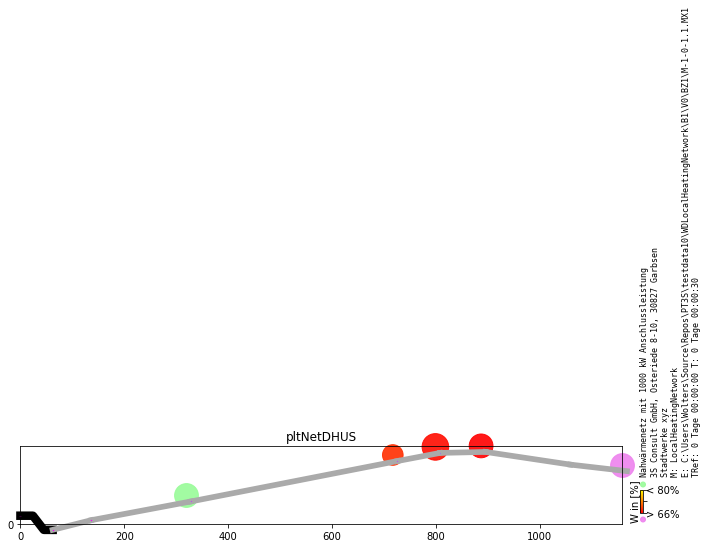

In [9]:
%run test.py --testDir testdata10 

INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata09
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata09
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata09
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata09
INFO    ; __main__.<module>: Start unittests (by DocTestSuite...). testDir: testdata09


Finding tests in Mx


.
----------------------------------------------------------------------
Ran 1 test in 27.021s

OK


Finding tests in Xm


.
----------------------------------------------------------------------
Ran 1 test in 77.714s

OK


Finding tests in Rm


.
----------------------------------------------------------------------
Ran 1 test in 7.159s

OK
INFO    ; __main__.<module>: Start doctests. testDir: testdata09
INFO    ; __main__.<module>: Start doctests. testDir: testdata09
INFO    ; __main__.<module>: Start doctests. testDir: testdata09
INFO    ; __main__.<module>: Start doctests. testDir: testdata09
INFO    ; __main__.<module>: Start doctests. testDir: testdata09


Finding tests in Mx
Finding tests in Xm
Finding tests in Rm


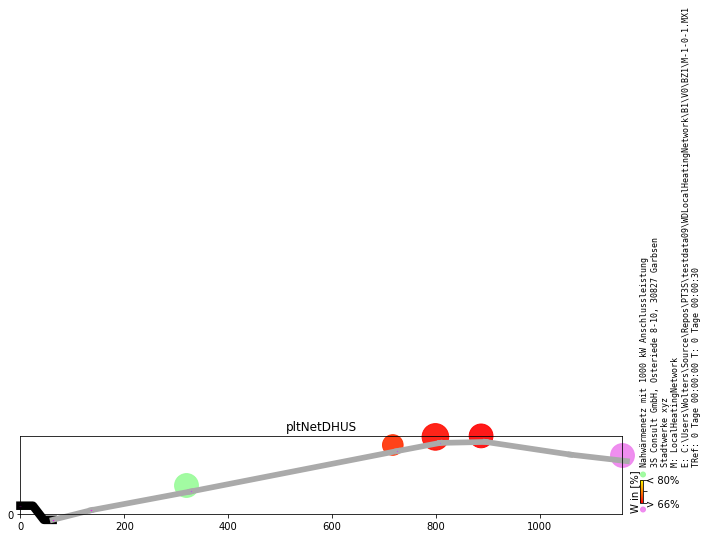

In [10]:
%run test.py --testDir testdata09 --dotResolution NONE

# Modell und Ergebnisse laden und nutzen

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import networkx as nx

## Modell

In [12]:
path='.'
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [13]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['BESCHREIBUNG','NAME_i','NAME_k','LAYR','L','D']).sort_index(level=1)

BESCHREIBUNG       NAME_i  NAME_k             LAYR       L      D
OBJTYPE OBJID                                                                                                  
ROHR    4613782368750024999                           None       R-K004  R-K005       [Rücklauf]   88.02  107.1
        4614949065966596185                           None       V-K002  V-K003        [Vorlauf]  405.96  107.1
        4637102239750163477                           None       R-K003  R-K004       [Rücklauf]   83.55  107.1
FWVB    4643800032883366034                              1       V-K002  R-K002  [Kundenanlagen]       0    NaN
VENT    4678923650983295610                           None          V-1     V-L        [Vorlauf]       0    150
FWVB    4704603947372595298                              3       V-K004  R-K004  [Kundenanlagen]       0    NaN
ROHR    4713733238627697042                           None       V-K004  V-K005        [Vorlauf]   88.02  107.1
        4769996343148550485                           None          R-L  R-K000       [Rücklauf]   73.42  160.3
        4789218195240364437                           None       V-K001  V-K002        [Vorlauf]  195.53  107.1
KLAP    4801110583764519435                           None           R2      R3       [Rücklauf]       0     80
VENT    4897018421024717974                           None          R-L     R-1       [Rücklauf]       0    150
ROHR    4939422678063487923                           None          V-L  V-K000        [Vorlauf]    68.6  160.3
        4945727430885351042                           None       R-K006  R-K007       [Rücklauf]  109.77  107.1
        4984202422877610920                           None       V-K000  V-K001        [Vorlauf]    76.4  107.1
PGRP    4986517622672493603                   Pumpengruppe          R-1      R3               []       0    NaN
ROHR    5037777106796980248                           None       V-K003  V-K004        [Vorlauf]   83.55  107.1
FWVB    5121101823283893406                              4       V-K005  R-K005  [Kundenanlagen]       0    NaN
ROHR    5123819811204259837                           None       V-K005  V-K006        [Vorlauf]  164.91  107.1
        5266224553324203132                           None       R-K001  R-K002       [Rücklauf]  195.53  107.1
        5379365049009065623                           None       R-K002  R-K003       [Rücklauf]  405.96  107.1
FWVB    5400405917816384862                              5       V-K007  R-K007  [Kundenanlagen]       0    NaN
PUMP    5481331875203087055                    Umwälzpumpe          R-1      R2       [Rücklauf]       0    NaN
VENT    5525310316015533093                           None  PKON-Knoten     R-1       [Rücklauf]       0     50
ROHR    5611703699850694889                           None       R-K005  R-K006       [Rücklauf]  164.91  107.1
        5620197984230756681                           None       V-K006  V-K007        [Vorlauf]  109.77  107.1
FWES    5638756766880678918  BHKW - Modul - 1000 kW therm.           R3     V-1        [Vorlauf]       0     80
ROHR    5647213228462830353                           None       R-K000  R-K001       [Rücklauf]    76.4  107.1
FWVB    5695730293103267172                              2       V-K003  R-K003  [Kundenanlagen]       0    NaN

In [14]:
vVBEL.dtypes

BESCHREIBUNG    object
IDREFERENZ      object
tk              object
NAME_i          object
CONT_i          object
CONT_VKNO_i     object
Z_i             object
pk_i            object
NAME_k          object
CONT_k          object
CONT_VKNO_k     object
Z_k             object
pk_k            object
LAYR            object
L               object
D               object
dtype: object

In [15]:
[viewOrTable for viewOrTable in sorted(xm.dataFrames.keys())]

['AGSN',
 'ALLG',
 'ALLG_BZ',
 'ARRW',
 'ATMO',
 'AVOS',
 'AVOS_ROWS',
 'BZAG',
 'BZAG_BZ',
 'CONT',
 'DATENEBENE',
 'DPGR',
 'DPGR_BZ',
 'DPGR_DPKT',
 'DPKT',
 'DRNP',
 'DTRO',
 'DTRO_ROWD',
 'EBES',
 'EBES_BZ',
 'ELEMENTQUERY',
 'ETAM',
 'ETAM_ROWS',
 'ETAR',
 'ETAR_ROWS',
 'ETAU',
 'ETAU_ROWS',
 'FSTF',
 'FWBZ',
 'FWES',
 'FWES_BZ',
 'FWVB',
 'FWVB_BZ',
 'GMIX',
 'GRAV',
 'GTXT',
 'KLAP',
 'KLAP_BZ',
 'KNOT',
 'KNOT_BZ',
 'LAYR',
 'LFAL',
 'LFAL_BZ',
 'LFKT',
 'LFKT_ROWT',
 'LTGR',
 'MAPG',
 'MAPG_ROWS',
 'MODELL',
 'NRCV',
 'PARI',
 'PARI_BZ',
 'PARV',
 'PARZ',
 'PARZ_BZ',
 'PGPR',
 'PGRP',
 'PGRP_BZ',
 'PGRP_PUMP',
 'PGRP_PUMP_BZ',
 'PHI1',
 'PHI1_ROWT',
 'PHI2',
 'PHI2_ROWS',
 'PHIV',
 'PHIV_ROWS',
 'PUMD',
 'PUMD_ROWT',
 'PUMK',
 'PUMK_ROWS',
 'PUMP',
 'PUMP_BZ',
 'PVAR',
 'PVAR_ROWT',
 'PZON',
 'PZVR',
 'PZVR_BZ',
 'QVAR',
 'QVAR_ROWT',
 'RART',
 'RART_BZ',
 'RCON',
 'RECT',
 'REGP',
 'ROHR',
 'ROHR_BZ',
 'RPFL',
 'RPLAN',
 'SIRGRAF',
 'SOKO',
 'SPLZ',
 'STOF',
 'STOF_ROWS',
 '

## Ergebnisse

In [16]:
(wDir,modelDir,modelName,mx1File)=xm.getWDirModelDirModelName()  

In [17]:
mx=Mx.Mx(mx1File=mx1File)

### Non-Vector

In [18]:
mx.df.filter(items=['ALLG~~~4639827058859487185~SNAPSHOTTYPE','KNOT~V-L~~5736262931552588702~PH'])

,ALLG~~~4639827058859487185~SNAPSHOTTYPE,KNOT~V-L~~5736262931552588702~PH
2004-09-22 08:30:00+00:00,b'STAT',4.125885
2004-09-22 08:30:15+00:00,b'TIME',3.161917
2004-09-22 08:30:30+00:00,b'TIME',2.597010
2004-09-22 08:30:45+00:00,b'TIME',2.207440
2004-09-22 08:31:00+00:00,b'TIME',4.125866


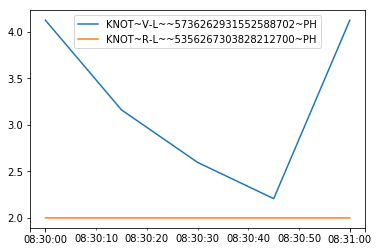

In [19]:
mx.df.filter(regex='^KNOT').filter(regex='PH$').plot()

### Vector

In [20]:
timesReq=mx.df.index.tolist()
mxVecsFileData=mx.getMxsVecsFileData(timesReq)
for vecsFileResult in mxVecsFileData:
    print(vecsFileResult.index)

DatetimeIndex(['2004-09-22 08:30:00+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:15+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:30+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:30:45+00:00'], dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2004-09-22 08:31:00+00:00'], dtype='datetime64[ns, UTC]', freq=None)


In [21]:
vecsFileResult.filter(regex='^ROHR').filter(regex='^(?!.*VEC)')

,ROHR~*~*~*~QMI,ROHR~*~*~*~VI,ROHR~*~*~*~VK,ROHR~*~*~*~QMK,ROHR~*~*~*~QMAV,ROHR~*~*~*~VAV,ROHR~*~*~*~IAKTIV
2004-09-22 08:31:00+00:00,"(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-8.509474754333496, 19.05978012084961, -15.378900527954102, 8.509475708007812, -22.987945556640625, 22.987945556640625, 22.987947463989258, -3.928166389465332, 22.987947463989258, 15.378901481628418, 3.928166627883911, -22.987945556640625, -19.059778213500977, -3.928166389465332, 3.928166627883911, -22.987945556640625)","(-0.26672810316085815, 0.6085612773895264, -0.4820491075515747, 0.2716997563838959, -0.3216458857059479, 0.7339840531349182, 0.32764118909835815, -0.12312773615121841, 0.7339840531349182, 0.49103420972824097, 0.12542276084423065, -0.7205533981323242, -0.597425639629364, -0.12312772870063782, 0.12542276084423065, -0.7205533981323242)","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)"


In [22]:
vecsFileResult.filter(regex='^KNOT')

,KNOT~*~*~*~P,KNOT~*~*~*~HMAX_INST,KNOT~*~*~*~H,KNOT~*~*~*~T,KNOT~*~*~*~PDAMPF,KNOT~*~*~*~HMIN_INST,KNOT~*~*~*~PMIN_INST,KNOT~*~*~*~RHO,KNOT~*~*~*~PMAX_INST,KNOT~*~*~*~WALTER,KNOT~*~*~*~PH,KNOT~*~*~*~IAKTIV
2004-09-22 08:31:00+00:00,"(3.3029706478118896, 4.985827445983887, 5.083365440368652, 5.121476650238037, 3.043287992477417, 3.2835655212402344, 3.004936695098877, 5.311289310455322, 5.126001358032227, 3.30965518951416, 5.291572570800781, 3.0001327991485596, 3.1414403915405273, 4.825952053070068, 3.0, 4.819449424743652, 3.3146581649780273, 4.8165812492370605, 3.3126587867736816, 3.0, 4.845085620880127, 5.125866413116455, 4.814672470092773)","(2.3029708862304688, 3.9858460426330566, 4.083384037017822, 4.121495246887207, 2.043287992477417, 2.2835655212402344, 2.004936695098877, 4.311307907104492, 4.1260199546813965, 2.30965518951416, 4.291591167449951, 2.0001327991485596, 2.1414403915405273, 3.8259706497192383, 2.0, 3.819467782974243, 2.3146584033966064, 3.8165998458862305, 2.3126590251922607, 2.0, 3.8451039791107178, 4.125884532928467, 3.8146908283233643)","(2.3029706478118896, 3.9858274459838867, 4.083365440368652, 4.121476650238037, 2.043287992477417, 2.2835655212402344, 2.004936695098877, 4.311289310455322, 4.126001358032227, 2.30965518951416, 4.291572570800781, 2.0001327991485596, 2.1414403915405273, 3.8259522914886475, 2.0, 3.8194491863250732, 2.3146581649780273, 3.8165812492370605, 2.3126587867736816, 2.0, 3.845085620880127, 4.125866413116455, 3.8146722316741943)","(60.0, 90.0, 90.0, 90.0, 60.0, 60.0, 60.0, 60.0, 90.0, 60.0, 60.0, 60.0, 60.0, 90.0, 60.0, 90.0, 60.0, 90.0, 60.0, 60.0, 90.0, 90.0, 90.0)","(0.19919998943805695, 0.7010999917984009, 0.7010999917984009, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.7010999917984009, 0.19919998943805695, 0.19919998943805695, 0.7010999917984009, 0.7010999917984009, 0.7010999917984009)","(2.0520989894866943, 2.1830272674560547, 2.20000958442688, 2.2066452503204346, 2.007716655731201, 2.0488641262054443, 2.0009095668792725, 2.2489211559295654, 2.2074618339538574, 2.053239107131958, 2.234363555908203, 2.000021457672119, 2.0251381397247314, 2.1569042205810547, 2.0, 2.155820608139038, 2.054123640060425, 2.1553244590759277, 2.053770065307617, 2.0, 2.1600239276885986, 2.20743989944458, 2.154994249343872)","(3.0520989894866943, 3.1830272674560547, 3.20000958442688, 3.2066452503204346, 3.007716655731201, 3.0488641262054443, 3.0009095668792725, 3.2489211559295654, 3.2074618339538574, 3.053239107131958, 3.234363555908203, 3.000021457672119, 3.0251381397247314, 3.1569042205810547, 3.0, 3.155820608139038, 3.054123640060425, 3.1553244590759277, 3.053770065307617, 3.0, 3.1600239276885986, 3.20743989944458, 3.154994249343872)","(983.7000122070312, 965.7000122070312, 965.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 965.7000122070312, 983.7000122070312, 983.7000122070312, 965.7000122070312, 965.7000122070312, 965.7000122070312)","(3.3029708862304688, 4.985846042633057, 5.083384037017822, 5.121495246887207, 3.043287992477417, 3.2835655212402344, 3.004936695098877, 5.311307907104492, 5.1260199546813965, 3.30965518951416, 5.291591167449951, 3.0001327991485596, 3.1414403915405273, 4.825970649719238, 3.0, 4.819467544555664, 3.3146584033966064, 4.8165998458862305, 3.3126590251922607, 3.0, 4.845104217529297, 5.125884532928467, 4.814690589904785)","(0.20900359749794006, 0.16107229888439178, 0.08707356452941895, 0.058159828186035156, 0.40391021966934204, 0.20748744904994965, 0.4333629012107849, 0.49676936864852905, 0.0, 0.286059081

## Modell und Ergebnis "synchronisieren"

In [ ]:
xm.MxSync(mx=mx)

In [ ]:
vROHR=xm.dataFrames['vROHR']

In [ ]:
vROHR[['L','mx2NofPts','mx2Idx']]

## Modellsichten um Ergebnisse "ergänzen"

In [ ]:
xm.MxAdd(mx=mx)

### Vektorergebnisse

In [ ]:
vKNOT=xm.dataFrames['vKNOT']
vKNOT.dtypes

In [ ]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['NAME_i','NAME_k','Z_i','KNOT~*~*~*~PH_i','Q']).sort_values(['Q','KNOT~*~*~*~PH_i'], ascending=[1,0])

In [ ]:
vVBEL.dtypes

In [ ]:
vROHR=xm.dataFrames['vROHR']
vROHR.dtypes

In [ ]:
vFWVB=xm.dataFrames['vFWVB']
vFWVB.dtypes

### Rohrvektorergebnisse

In [ ]:
vROHRVecResults=xm.dataFrames['vROHRVecResults']
vROHRVecResults[['pk','mx2Idx','IptIdx','ROHR~*~*~*~SVEC','ROHR~*~*~*~ZVEC','ROHR~*~*~*~MVEC']]

## Schnitte

In [ ]:
vAGSN=xm.dataFrames['vAGSN']

In [ ]:
vAGSN.dtypes

In [ ]:
dfOneVL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
dfOneVL[['OBJTYPE','x','P','Q']]

In [ ]:
plt.plot(dfOneVL['x'],dfOneVL['Q'])

In [ ]:
plt.plot(dfOneVL['x'],dfOneVL['P'])

## Store in H5

In [ ]:
xm.ToH5()
mx.ToH5()
# next read will be faster because H5 is read instead of XML / MX if H5 is newer than XML / MX

In [ ]:
xm=Xm.Xm(xmlFile=xmlFile)

In [ ]:
mx=Mx.Mx(mx1File=mx1File)

In [ ]:
#xm?

In [ ]:
#mx?

# Rm Plot Beispiele

In [ ]:
rm=Rm.Rm(xm=xm,mx=mx)

## Bsp1: Prozentdarstellung - keine Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
    
                 ,pVICsDf=pd.DataFrame({'Kundenname': ['VIC1'],'Knotenname': ['V-K007']})
    
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

# NetworkX und SciPy Beispiele

In [ ]:
G=nx.from_pandas_edgelist(xm.dataFrames['vVBEL'], source='NAME_i', target='NAME_k', edge_attr=True,create_using=nx.MultiGraph())

In [ ]:
for e, datadict in G.edges.items():
    print(e)
    print(datadict)

In [ ]:
for n, nbrsdict in G.adj.items():
    print("!{0:s}".format(n))
    for nox, mgdct in nbrsdict.items(): 
        print("   {0:s}".format(nox))
        for mg,edct in  mgdct.items():
            print("        {0:d}: {1:s}".format(mg,str(edct))) 

In [ ]:
print(nx.dijkstra_path(G, 'V-L', 'R-L'))

In [ ]:
max([d for n,d in nx.degree(G)]) 

In [ ]:
spmtx=nx.adjacency_matrix(G) # Return type: SciPy sparse matrix
plt.spy(spmtx)

Die Laplace-Matrix ist definiert als  L:=D-A, wobei  D die Gradmatrix und  A die Adjazenzmatrix des Graphen bezeichnet.

In [ ]:
spmtx=nx.laplacian_matrix(G)
plt.spy(spmtx)

In [ ]:
nl=[n for n in G.nodes()]

In [ ]:
A=nx.to_scipy_sparse_matrix(G)

In [ ]:
nlo=scipy.sparse.csgraph.reverse_cuthill_mckee(A)

In [ ]:
optnl=[nl[idx] for idx in nlo]

In [ ]:
spmtx=nx.laplacian_matrix(G,nodelist=optnl)
plt.spy(spmtx)

## Clean Up

In [ ]:
if os.path.exists(xm.h5File):                        
    os.remove(xm.h5File)
if os.path.exists(mx.h5FileVecs):                        
    os.remove(mx.h5FileVecs)
if os.path.exists(mx.h5File):                        
    os.remove(mx.h5File)

# Deploy

python setup.py clean sdist bdist_wheel 

pip install twine

twine upload dist/*

# Develop

In [ ]:
###!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S or from PT3S import ...

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git